# Notebook to select the Andromeda RGB+AGB targets for Spec-S5

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LogNorm, PowerNorm
from matplotlib.patches import Polygon
from matplotlib.path import Path

from glob import glob
import random

import pandas as pd

from astropy.table import Table, join
from astropy.table import vstack
from astropy.io import fits, ascii
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
import fitsio
import healpy as hp

from desitarget.targetmask import desi_mask, mws_mask

from datetime import datetime,date

import dustmaps.sfd

plt.rcParams["font.size"] = 12

In [11]:
def betw(x,xmin,xmax):
    imask = ((x > xmin) & (x < xmax))
    return imask

cosd = lambda x: np.cos(np.deg2rad(x))
sind = lambda x: np.sin(np.deg2rad(x))

In [13]:
# Define the center points of M31 and M33
m31ra, m31dec = 10.68470833, 41.26875
m33ra, m33dec = 23.461667, 30.6602
m31cen = SkyCoord(m31ra*u.deg,m31dec*u.deg, frame='fk5')

# Define the M31 radial velocity (km/s)
rvm31=-300.0 

# Define the ellipse for M31
t = np.arange(360)
a_e_m31 = 1.5
b_e_m31 = 0.337
PA0_m31=45.0 # major axis position angle in degrees
PA_m31=90-PA0_m31 # redefine the position angle so that it is measured counterclockwise from the EW axis

ra_m31ell=a_e_m31*cosd(t)*cosd(PA_m31)-b_e_m31*sind(t)*sind(PA_m31)+m31ra
dec_m31ell=a_e_m31*cosd(t)*sind(PA_m31)+b_e_m31*sind(t)*cosd(PA_m31)+m31dec

# Define the ellipse for M33
a_e_m33 = 0.5
b_e_m33 = 0.337
PA0_m33 = 35
PA_m33=90 - PA0_m33 # redefine the position angle so that it is measured counterclockwise from the EW axis

ra_m33ell=a_e_m33*cosd(t)*cosd(PA_m33)-b_e_m33*sind(t)*sind(PA_m33)+m33ra
dec_m33ell=a_e_m33*cosd(t)*sind(PA_m33)+b_e_m33*sind(t)*cosd(PA_m33)+m33dec

## Read in the Combined PAndAS+Gaia+UnWISE Photometric Catalog

In [14]:
# Read in the photometric data table
#inphot = '~/desi/users/koposov/m31_all/m31_extension/data/m31_pandas_gaia_wise_250715.fits'
inphot = '/global/cfs/cdirs/desi/users/sandford/m31_dedicated_tile/tertiary_files/inputcats/data/desi_input_target_catalog_260116.fits'
T=Table.read(inphot,mask_invalid=False)

In [15]:
# Add a column of the estimated z-band magnitude
# First estimate the z-band mag from the PAndAS g-i color for the PAndAS sources:
Tgz = (np.maximum(((T['PANDAS_G'] - T['PANDAS_I']) - 1.8) * 0.15, -(T['PANDAS_G'] - T['PANDAS_I']) - 1.8) *
       0.03) - 0.13 + 1.3 * (T['PANDAS_G'] - T['PANDAS_I'])
zmag = T['PANDAS_G'] - Tgz
# For the Gaia-only sources we use a different relation
zmag[~np.isfinite(zmag)] = (0.36+T['GAIA_PHOT_G_MEAN_MAG']-0.7*(T['GAIA_PHOT_BP_MEAN_MAG']-
                                                        T['GAIA_PHOT_RP_MEAN_MAG'])+
                    0.06*(T['GAIA_PHOT_BP_MEAN_MAG']-T['GAIA_PHOT_RP_MEAN_MAG']-1.5)**2)[~np.isfinite(zmag)]
T['zmag'] = zmag

In [16]:
# Correct the PAndAS photometry for the MW dust extinction using the Schlegel-Finkbeiner-Davis dust maps
ebv = dustmaps.sfd.SFDQuery().query_equ(T['RA'], T['DEC'])
# ebv1 = np.clip(ebv, 0, .1 + ((XP_dx**2 + XP_dy**2) > 1.5**2).astype(int))
XP_dx, XP_dy = (((T['RA'] + 180) % 360 - 180 - m31ra) *
                np.cos(np.deg2rad(m31dec)), (T['DEC'] - m31dec))
ebv1 = np.where((XP_dx**2 + XP_dy**2) > 1.5**2, ebv, np.clip(ebv, 0, .09))
T['ebv1'] = ebv1
ext_g = 3.8  # rounded from ibata 2014
ext_i = 2.1
T['g0'] = T['PANDAS_G'] - ext_g * T['ebv1']
T['i0'] = T['PANDAS_I'] - ext_i * T['ebv1']

# Correct the z-band magnitude for extinction using the Schlegel-Finkbeiner-Davis dust maps
ext_z = 1.211
T['zmag0'] = T['zmag'] - ext_z * T['ebv1']


In [17]:
T

EBV,REF_EPOCH,PMRA,PMDEC,PARALLAX,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,NU_EFF_USED_IN_ASTROMETRY,PSEUDOCOLOUR,ASTROMETRIC_EXCESS_NOISE,RA,DEC,ECL_LAT,SOURCE_ID,ASTROMETRIC_PARAMS_SOLVED,BRICKID,OBJID,REF_ID,REF_CAT,PHOTSYS,RELEASE,BRICKNAME,MASKBITS,TYPE,FLUX_G,FLUX_IVAR_G,FLUX_R,FLUX_IVAR_R,FLUX_Z,FLUX_IVAR_Z,FLUX_W1,FLUX_IVAR_W1,W1MPRO,FLUX_W2,FLUX_IVAR_W2,W2MPRO,FLUX_J,FLUX_IVAR_J,J,FLUX_K,FLUX_IVAR_K,K,PMRA_IVAR,PMDEC_IVAR,PARALLAX_IVAR,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PANDAS_G,PANDAS_I,RANDOM,IS_SPECIAL_OBJECT,UKIRT_J,UKIRT_K,UKIRT_J_ERR,UKIRT_K_ERR,IS_AGB,RVS_FLAG,zmag,ebv1,g0,i0,zmag0
float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,int64,bool,int32,int32,int64,bytes3,bytes5,int64,bytes8,int16,bytes4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float32,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,bool,float64,float64,float64,float64,bool,bool,float32,float32,float32,float32,float32
0.10442942,2016.0,-5.8522415,-5.1596117,3.032004,10.604388,10.866405,10.18153,1.5883309,0.0,0.109328255,25.758607950285096,25.018818148755873,13.377846643051235,291456240188848384,True,33134,150,291456240188848384,G3,G,7777,,0,GPSF,13350.169,-99.0,30980.191,-99.0,16014.255,-99.0,167957.8,2.9019228e-07,9.437,166418.06,6.6507056e-07,9.447,0.0,0.0,nan,0.0,0.0,nan,2041.9314,3337.7612,2406.2214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.30204269064024003,False,0.0,0.0,0.0,0.0,False,False,0.1381,0.10442942,-0.39683178,-0.21930176,0.011635974
0.10341504,2016.0,17.33586,3.4878497,2.26889,18.974356,20.67611,17.748327,1.2638394,0.0,0.0,25.74978106288235,25.031913165897016,13.392966829416554,291456308908398336,True,33134,151,291456308908398336,G3,G,7777,,0,GPSF,4.0962358,-99.0,16.836208,-99.0,109.39687,-99.0,903.64966,0.0039989064,15.11,997.2408,0.0015119328,15.003,0.0,0.0,nan,0.0,0.0,nan,13.580183,16.547699,14.254949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8636740110614243,False,0.0,0.0,0.0,0.0,False,False,0.1381,0.10341504,-0.39297715,-0.21717158,0.012864381
0.102714196,2016.0,11.745381,-17.912378,0.7991352,19.704279,20.885445,18.666262,0.0,1.574557,0.90354776,25.863758315573605,25.05485217236286,13.376284025248216,291457374060295424,True,33134,186,291457374060295424,G3,G,7777,,0,GPSF,2.8061285,-99.0,11.0188,-99.0,44.289616,-99.0,345.4621,0.01097502,16.154,331.13092,0.0016798449,16.2,0.0,0.0,nan,0.0,0.0,nan,4.3686914,5.8265166,2.620031,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.877821259255589,False,0.0,0.0,0.0,0.0,False,False,0.1381,0.102714196,-0.39031395,-0.2156998,0.013713114
0.10252022,2016.0,28.48313,-13.9465275,2.495615,18.93196,20.381317,17.775187,1.2704864,0.0,0.0,25.87875426715687,25.05696689944413,13.373252772080422,291457374060296064,True,33134,187,291457374060296064,G3,G,7777,,0,GPSF,4.4757667,-99.0,19.95776,-99.0,101.95317,-99.0,917.0652,0.0038827644,15.094,981.7476,0.0011943976,15.02,0.0,0.0,nan,0.0,0.0,nan,12.726634,15.119112,13.100765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9321963466196128,False,0.0,0.0,0.0,0.0,False,False,0.1381,0.10252022,-0.38957682,-0.21529245,0.013948016
0.10252357,2016.0,-2.360104,-3.7350235,0.038860105,18.616545,19.207836,17.820559,1.4386514,0.0,0.0,25.883262092045257,25.064384481233233,13.378648102577667,291457408420036224,True,33134,188,291457408420036224,G3,G,7777,,0,GPSF,18.921753,-99.0,42.233692,-99.0,66.23544,-99.0,316.22775,0.011511944,16.25,300.88446,0.0015724123,16.304,0.0,0.0,nan,0.0,0.0,nan,20.897257,24.918142,21.339127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5965291448740513,False,0.0,0.0,0.0,0.0,False,False,0.1381,0.10252357,-0.38958958,-0.21529949,0.013943955
0.10341172,2016.0,0.0,0.0,0.0,21.024372,19.30125,17.448

In [18]:
# Define the distances of the sources from M31 and M33
coord1 = SkyCoord(ra=T['RA']*u.degree, dec=T['DEC']*u.degree, frame='icrs')
coord2 = SkyCoord(ra=m31ra*u.degree, dec=m31dec*u.degree, frame='icrs')
coord3 = SkyCoord(ra=m33ra*u.degree, dec=m33dec*u.degree, frame='icrs')

# Compute the angular separation
DM31 = coord1.separation(coord2)
DM33 = coord1.separation(coord3)

## Investigate the M31 RGB/AGB Candidate sources

In [19]:
# For all selections not involving the cluster catalog, use this mask
# It selects all sources which do not have any entry in the 'OBJECT' column (which is from the Caldwell catalog)
# inocl = (Tnew['src_origin'] != 'cl') -- THIS VERSION DOES NOT INCLUDE THE CLUSTERS

#Old astmask using errors instead of inverse variances:
#astmask = ((np.abs(Tnew['PMRA']) < 0.05+ 2*Tnew['PMRA_ERROR']) & 
#           (np.abs(Tnew['PMDEC'])< 0.05+ 2*Tnew['PMDEC_ERROR']) & 
#           (Tnew['PARALLAX']<0.05 + 2*Tnew['PARALLAX_ERROR'])) | (~np.isfinite(Tnew['PMRA']))

#astmask = ((np.abs(Tnew['PMRA']) < 0.05+ 2.0/np.sqrt(Tnew['PMRA_IVAR'])) & 
#           (np.abs(Tnew['PMDEC'])< 0.05+ 2.0/np.sqrt(Tnew['PMDEC_IVAR'])) & 
#           (Tnew['PARALLAX']<0.05 + 2.0/np.sqrt(Tnew['PARALLAX_IVAR']))) | (~np.isfinite(Tnew['PMRA']))

pmra_error = 1./np.sqrt(T['PMRA_IVAR'])
pmdec_error = 1./np.sqrt(T['PMDEC_IVAR'])
parallax_error = 1./np.sqrt(T['PARALLAX_IVAR'])
i = ~np.isfinite(pmra_error)
pmra_error[i]=0
i = ~np.isfinite(pmdec_error)
pmdec_error[i]=0
i = ~np.isfinite(parallax_error)
parallax_error[i]=0

astmask = ((np.abs(T['PMRA']) < 0.05+ 2.0*pmra_error) & 
           (np.abs(T['PMDEC'])< 0.05+ 2.0*pmdec_error) & 
           (T['PARALLAX']<0.05 + 2.0*parallax_error)) | (~np.isfinite(T['PMRA']))


/tmp/ipykernel_626715/3589448365.py:14: RuntimeWarning: divide by zero encountered in true_divide
  pmra_error = 1./np.sqrt(T['PMRA_IVAR'])
/tmp/ipykernel_626715/3589448365.py:15: RuntimeWarning: divide by zero encountered in true_divide
  pmdec_error = 1./np.sqrt(T['PMDEC_IVAR'])
/tmp/ipykernel_626715/3589448365.py:16: RuntimeWarning: divide by zero encountered in true_divide
  parallax_error = 1./np.sqrt(T['PARALLAX_IVAR'])


In [21]:
# Selection based on the DESI 
minmag = 20.5
maxmag = 24.0
col1 = (T['g0']-T['i0']+(T['i0']-22.5)/3.5)
col2 = (T['g0']-T['i0']+(T['i0']-22.5)/4.0)
rgbmask = (astmask &  
           (T['i0'] >= minmag) & (T['i0'] <= maxmag) & 
           (col1 >= 1.0) & 
           ((col1 <= 1.5) | (T['i0'] <= 23.5-(T['g0']-T['i0']))) &
           (T['i0'] >= minmag-0.1+0.2*(T['g0']-T['i0'])) &
           (T['TYPE'] == "PPSF")) # new version of PAndAS morphology flag created by Sergey which is equivalent to ii<=-1
           #(Tnew['ii'] <= -1)) # Original PAndAS morphology flag -- "−1" indicates a source that is within 1σ of the locus of point sources (i.e., very probably a point source)
ilowfe = ((col1 <= 1.5) | (col2 <= 1.4))
iintfe = ((col1  > 1.5) & (col2  > 1.4))
print(f'Number of Old RGB candidates = {rgbmask.sum()}')
print(f'      Number of low-metallicity RGB candidates = {(rgbmask & ilowfe).sum()}')
print(f'      Number of intermediate-metallicity RGB candidates = {(rgbmask & iintfe).sum()}')

Number of Old RGB candidates = 2609746
      Number of low-metallicity RGB candidates = 2260253
      Number of intermediate-metallicity RGB candidates = 349493


### Make a plot showing the selection on a CMD

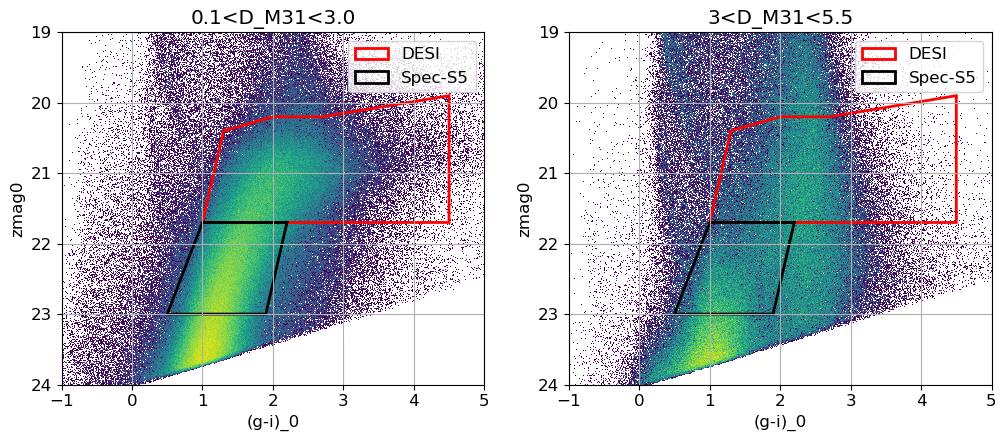

In [42]:
fig, axs = plt.subplots(1,2,figsize=(12, 8))

dmin,dmax = 0.1,3.0
imask=betw(DM31.degree,dmin,dmax)
ax=axs[0]
ax.hist2d((T['g0']-T['i0'])[imask],T['zmag0'][imask],range=[[-1,5],[19,24]],bins=[1000,1000],norm=LogNorm())

vertices_desi = [(1,21.7),(4.5,21.7),(4.5,19.9),(2.7,20.2),(2.0,20.2),(1.3,20.4),(1,21.7)]
vertices_spec5 = [(0.5,23.0),(1.9,23.),(2.2,21.7),(1.,21.7),(0.5,23)] # RGB Faint

poly_desi = Polygon(vertices_desi, closed=True, facecolor='none', edgecolor='red', linewidth=2,label='DESI')
poly_spec5 = Polygon(vertices_spec5, closed=True, facecolor='none', edgecolor='black', linewidth=2,label='Spec-S5')

ax.add_patch(poly_desi)
ax.add_patch(poly_spec5)

ax.set_aspect('equal')
ax.grid(True)
ax.set_ylim(24,19)
ax.set_xlabel('(g-i)_0')
ax.set_ylabel('zmag0')
ax.set_title(f'{dmin}<D_M31<{dmax}')
ax.legend()

dmin,dmax = 3,5.5
imask=betw(DM31.degree,dmin,dmax)
ax=axs[1]
ax.hist2d((T['g0']-T['i0'])[imask],T['zmag0'][imask],range=[[-1,5],[19,24]],bins=[1000,1000],norm=LogNorm())

poly_desi = Polygon(vertices_desi, closed=True, facecolor='none', edgecolor='red', linewidth=2,label='DESI')
poly_spec5 = Polygon(vertices_faint, closed=True, facecolor='none', edgecolor='black', linewidth=2,label='Spec-S5')

ax.add_patch(poly_desi)
ax.add_patch(poly_spec5)

ax.set_aspect('equal')
ax.grid(True)
ax.set_ylim(24,19)
ax.set_xlabel('(g-i)_0')
ax.set_ylabel('zmag0')
ax.set_title(f'{dmin}<D_M31<{dmax}')
ax.legend()

plt.savefig('SpecS5_Andromeda_cmd_selection.png')
plt.show()

## Select the RGB+AGB Targets for M31

In [43]:
# Define the polygons for the DESI and Spec-S5 selections:
vertices_desi = [(1,21.7),(4.5,21.7),(4.5,19.9),(2.7,20.2),(2.0,20.2),(1.3,20.4),(1,21.7)]
vertices_spec5 = [(0.5,23.0),(1.9,23.),(2.2,21.7),(1.,21.7),(0.5,23)] # RGB Faint

# make a Path object

path_desi = Path(vertices_desi)
path_spec5 = Path(vertices_spec5)

# Define the space
x = T['g0']-T['i0']
y = T['zmag0']
points = np.column_stack((x, y))

# Test which points are inside the polygon
indesi = path_desi.contains_points(points)
inspec5 = path_spec5.contains_points(points)

# Define the good photometry mask
goodphot = np.isfinite(T['g0']) & np.isfinite(T['i0'])

# Final masks for target selection
desi_sel = astmask & goodphot & indesi
spec5_sel = astmask & goodphot & inspec5

# Stats
print(f'Number of targets in desi selection = {desi_sel.sum()}')
print(f'Number of targets in spec5 selection = {spec5_sel.sum()}')
print(f'Total number = {(spec5_sel | desi_sel).sum()}')
dmin,dmax = 0.,5.5
imask=betw(DM31.degree,dmin,dmax)
print(f' Within {dmax} degrees: ')
print(f'       Number of targets in desi selection = {(desi_sel & imask).sum()}')
print(f'       Number of targets in spec5 selection = {(spec5_sel & imask).sum()}')
print(f'       Total number = {(imask & (spec5_sel | desi_sel)).sum()}')


Number of targets in desi selection = 3256577
Number of targets in spec5 selection = 2688226
Total number = 5944803
 Within 5.5 degrees: 
       Number of targets in desi selection = 1563932
       Number of targets in spec5 selection = 1671979
       Total number = 3235911


In [44]:
tot = (imask & (spec5_sel | desi_sel)).sum()
print(f'Number of Spec-S5 nights required for 100% completeness = {(tot / 13000.)*6./9.5/.7 : .1f}')

Number of Spec-S5 nights required for 100% completeness =  224.6


#### Surface density of stars selected by the RGBHI/LO/AGB regions

In [41]:
# Count the number of targets within the M31 and M33 regions
imask31 = betw(DM31.degree,0,5.5)
imask33 = betw(DM33.degree,0,2)
area31 = np.pi*(5.5**2)
area33 = np.pi*(2**2)
nm31 = np.array([(imask31 & spec5_sel).sum(),(imask31 & desi_sel).sum()])
nm33 = np.array([(imask33 & spec5_sel).sum(),(imask33 & desi_sel).sum()])
print(f'Average Density per sq degree of M31 Targets:')
tt = ['spec5','desi']
print(f' Mask    M31      M33')
for i in np.arange(2):
    print(f'{tt[i]:6s} {nm31[i]/area31:.1f}  {nm33[i]/area33:.1f}')
print(f'Total: {nm31.sum()/area31:.1f} {nm33.sum()/area33:.1f}')

Average Density per sq degree of M31 Targets:
 Mask    M31      M33
spec5  17593.6  9905.1
desi   16456.7  7996.0
Total: 34050.3 17901.1


### Make a plot to check if we are getting uniform selection in the rgbhi region

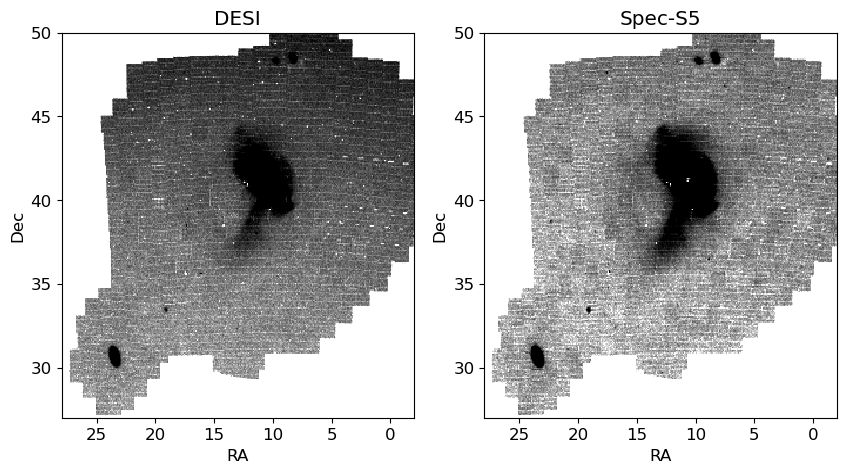

In [78]:
# Surface density plot of the three target types
fig, axs = plt.subplots(1,2,figsize=(10,5))

ra,dec = T['RA'],T['DEC']
i = (ra > 200)
ra[i] = ra[i]-360.0
ramin,ramax = np.min(ra),np.max(ra)
decmin,decmax = np.min(dec),np.max(dec)
ramin,ramax = -2,28
decmin,decmax = 27,50

ax=axs[0]
ax.hist2d(ra[desi_sel],dec[desi_sel],range=([ramin,ramax],[decmin,decmax]),bins=[300,300] \
          ,norm=LogNorm(vmin=5,vmax=100),cmap='gray_r')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.set_xlim(ramax,ramin)
ax.set_ylim(decmin,decmax)
ax.set_title('DESI')
#ax.set_aspect('equal')

ax=axs[1]
ax.hist2d(ra[spec5_sel],dec[spec5_sel],range=([ramin,ramax],[decmin,decmax]),bins=[300,300] \
#          ,norm=PowerNorm(gamma=0.2, vmin=10, vmax=200),cmap='gray_r')
          ,norm=LogNorm(vmin=5,vmax=100),cmap='gray_r')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.set_xlim(ramax,ramin)
ax.set_ylim(decmin,decmax)
ax.set_title('Spec-S5')
#ax.set_aspect('equal')

plt.savefig('SpecS5_Andromeda_desi_spec5.png')

plt.show()
